In [1]:
import numpy as np
import pandas as pd
import stan
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('/mrhome/amingk/Documents/7TPD/ActStimRL')
from Madule import utils
import arviz as az
from scipy.stats import gaussian_kde

In [2]:
def MAP(posterior_samples):
    # Estimate density
    kde = gaussian_kde(posterior_samples)

    # Evaluate KDE on a grid
    x = np.linspace(min(posterior_samples), max(posterior_samples), 1000)
    density = kde(x)

    # MAP estimate = location of the maximum density
    map_estimate = x[np.argmax(density)]
    return map_estimate, np.max(density)

In [15]:
# Read data fram of participatns
df = pd.read_csv('/mnt/projects/7TPD/bids/derivatives/fMRI_DA/AllBehData/NoNanBehAll.csv')


In [4]:
# wirtten main directory  
writeMainScarch = '/mnt/scratch/projects/7TPD/amin'
# name of model
model_name = 'tabel1_model3_complement_prob'
# The adrees name of pickle file
pickelDir = f'{writeMainScarch}/Behavioral/Tabel1/PD/{model_name}_PD.pkl'
"""Loading the pickle file of model fit from the subject directory"""
loadPkl = utils.load_pickle(load_path=pickelDir)
#loadPkl_PD = utils.load_pickle(load_path=pickelDir_PD)
fit = loadPkl['fit']

In [16]:
#####################Hierarchical Parameters
# Healthy Control
# Extracting posterior distributions for each of four main unkhown parameters
hier_weight_mu = fit["transfer_hier_weight_mu"] 
hier_alpha_pos_mu = fit["transfer_hier_alpha_pos_mu"].flatten()
hier_alpha_neg_mu = fit["transfer_hier_alpha_neg_mu"].flatten() 
hier_sensitivity_mu = fit["transfer_hier_sensitivity_mu"].flatten() 

weight = fit["transfer_weight"] 
alpha_pos = fit["transfer_alpha_pos"].flatten()
alpha_neg = fit["transfer_alpha_neg"].flatten() 
sensitivity = fit["transfer_sensitivity"].flatten() 


In [17]:
weight.shape, 

((24, 2, 24000),)

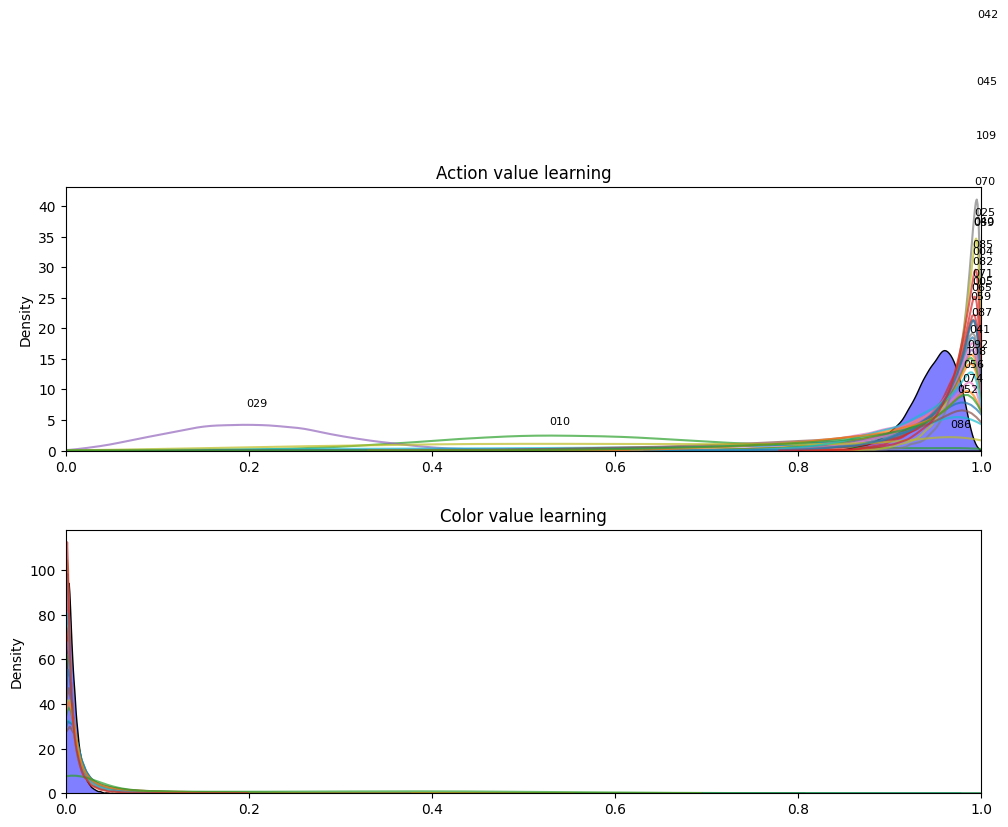

In [ ]:
mm = 1/2.54  # centimeters in inches
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(30*mm, 20*mm))
axs = axs.flatten()
 

# action calaue learning
for i in range(weight.shape[0]):
    # Session 1
    sns.kdeplot(data=weight[i,0], ax=axs[0], alpha=.7)
    map_apex, dens_apex=MAP(weight[i,0])
    sub_name = df[df['patient']=='PD']['sub_ID'].unique()[i]
    axs[0].text(map_apex, dens_apex/25,  sub_name[4:], transform=axs[0].transAxes, fontsize=8)

# hierarchical parametes
sns.kdeplot(data=hier_weight_mu[0], ax=axs[0], multiple="stack", color='blue', alpha=.5)
axs[0].set_xlim(0,1)
axs[0].set_title('Action value learning')
  
# color value learning
for i in range(weight.shape[0]):
    # Session 1
    sns.kdeplot(data=weight[i,1], ax=axs[1], alpha=.7)
  
# hierarchical parametes
sns.kdeplot(data=hier_weight_mu[1], ax=axs[1], multiple="stack", color='blue', alpha=.5)
axs[1].set_xlim(0,1)
axs[1].set_title('Color value learning')
 

fig.subplots_adjust(wspace=.3, hspace=.3)


In [ ]:
weight

In [27]:
#Outlier of weighting Parameters for HC -Color Value-session1
for i in range(len(transfer_weight_HC)):
    map_apex, dens_apex = MAP(transfer_weight_HC[i,0,1])
    if map_apex>.7:
        print(i, ': ', df[df['patient']=='HC']['sub_ID'].unique()[i])

2 :  sub-030


In [24]:
#Outlier of weighting Parameters for HC -Color Value-session2
for i in range(len(transfer_weight_HC)):
    map_apex, dens_apex = MAP(transfer_weight_HC[i,1,1])
    if map_apex>.7:
        print(i, ': ', df[df['patient']=='HC']['sub_ID'].unique()[i])

2 :  sub-030
12 :  sub-067


In [22]:
#Outlier of weighting Parameters for PD -Color Value-OFF
for i in range(len(transfer_weight_PD)):
    map_apex, dens_apex = MAP(transfer_weight_PD[i,0,1])
    if map_apex>.7:
        print(i, ': ', df[df['patient']=='PD']['sub_ID'].unique()[i])

9 :  sub-052
10 :  sub-056
12 :  sub-065
22 :  sub-108


In [23]:
#Outlier of weighting Parameters for PD -Color Value-ON
for i in range(len(transfer_weight_PD)):
    map_apex, dens_apex = MAP(transfer_weight_PD[i,1,1])
    if map_apex>.7:
        print(i, ': ', df[df['patient']=='PD']['sub_ID'].unique()[i])

5 :  sub-040
9 :  sub-052
22 :  sub-108


In [ ]:
#Outlier of weighting Parameters for PD -Action Value-OFF
for i in range(len(transfer_weight_PD)):
    map_apex, dens_apex = MAP(transfer_weight_PD[i,0,0])
    if map_apex<.3:
        print(i, ': ', df[df['patient']=='PD']['sub_ID'].unique()[i])

4 :  sub-029


In [26]:
#Outlier of weighting Parameters for PD -Action Value-ON
for i in range(len(transfer_weight_PD)):
    map_apex, dens_apex = MAP(transfer_weight_PD[i,1,0])
    if map_apex<.3:
        print(i, ': ', df[df['patient']=='PD']['sub_ID'].unique()[i])

4 :  sub-029
